In [ ]:
!pip install mediapipe torchvision tqdm

from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models import ResNet18_Weights
import torchvision.transforms as T
from dataclasses import dataclass
from tqdm import tqdm
import os

# GPU kontrolü
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kullanılan Cihaz: NVIDIA L4


In [ ]:
!unzip -q /content/drive/MyDrive/bitirme/dataset_lip/dataset_final.zip -d /content/

replace /content/dataset_final/test/data13/acıktım/acıktım1.pt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
import random
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass

@dataclass
class LipSample:
    frames_rgb:  torch.Tensor
    diff_frames: torch.Tensor
    mask:        torch.Tensor
    real_len:    int
    source_dur:  float
    video_path:  str

class LipReadingDataset(Dataset):
    def __init__(self, root_dir, class_to_idx, is_train=True, max_frames=90):
        self.file_paths = []
        self.labels = []
        self.is_train = is_train
        self.max_frames = max_frames
        self.color_jitter = T.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.2)

        print(f"📂 {root_dir} taranıyor...")
        for person in os.listdir(root_dir):
            if person.startswith('.'): continue
            person_path = os.path.join(root_dir, person)
            if not os.path.isdir(person_path): continue
            for word in os.listdir(person_path):
                if word.startswith('.'): continue
                word_path = os.path.join(person_path, word)
                if not os.path.isdir(word_path): continue
                if word in class_to_idx:
                    label_idx = class_to_idx[word]
                else:
                    continue
                for file in os.listdir(word_path):
                    if file.endswith('.pt'):
                        self.file_paths.append(os.path.join(word_path, file))
                        self.labels.append(label_idx)

        print(f"✅ {len(self.file_paths)} adet .pt dosyası hafızaya alındı.")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        sample = torch.load(self.file_paths[idx], weights_only=False)

        video = sample.frames_rgb  # (T, 3, H, W)
        diff  = sample.diff_frames # (T, 1, H, W)
        mask  = sample.mask        # (T,)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        T_current = video.size(0)
        if T_current < self.max_frames:
            pad_len = self.max_frames - T_current
            video = torch.cat([video, torch.zeros((pad_len, 3, 96, 96), dtype=video.dtype)], dim=0)
            diff  = torch.cat([diff,  torch.zeros((pad_len, 1, 96, 96), dtype=diff.dtype)],  dim=0)
            mask  = torch.cat([mask,  torch.zeros((pad_len,), dtype=mask.dtype)], dim=0)
        elif T_current > self.max_frames:
            video = video[:self.max_frames]
            diff  = diff[:self.max_frames]
            mask  = mask[:self.max_frames]

        if self.is_train:
            video = self.color_jitter(video)

            affine_transform = T.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.96, 1.04))
            video = affine_transform(video)

            if random.random() > 0.3:
                h, w = video.shape[2], video.shape[3]
                cut_h, cut_w = random.randint(10, 20), random.randint(10, 20)
                y = random.randint(0, h - cut_h)
                x = random.randint(0, w - cut_w)
                video[:, :, y:y+cut_h, x:x+cut_w] = 0.0
                diff[:, :, y:y+cut_h, x:x+cut_w] = 0.0

            if random.random() > 0.3:
                T_len = video.shape[0]
                mask_len = random.randint(4, 8)
                start_idx = random.randint(0, max(0, T_len - mask_len - 1))
                video[start_idx : start_idx + mask_len] = 0.0
                diff[start_idx : start_idx + mask_len] = 0.0

            noise = torch.randn_like(video) * 0.03
            video = torch.clamp(video + noise, 0.0, 1.0)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(video.dtype)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(video.dtype)
        video = (video - mean) / std

        return video, diff, mask, label

DATASET_ROOT = '/content/dataset_final'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'train')
VAL_DIR   = os.path.join(DATASET_ROOT, 'val')

def get_classes(root_dir):
    classes = set()
    for person in os.listdir(root_dir):
        if person.startswith('.'): continue
        person_path = os.path.join(root_dir, person)
        if os.path.isdir(person_path):
            for word in os.listdir(person_path):
                if word.startswith('.'): continue
                if os.path.isdir(os.path.join(person_path, word)):
                    classes.add(word)
    return sorted(list(classes))

class_list    = get_classes(TRAIN_DIR)
class_to_idx  = {cls_name: i for i, cls_name in enumerate(class_list)}
print(f"🎯 Toplam {len(class_list)} kelime sınıfı başarıyla indekslendi.")

BATCH_SIZE = 32
train_dataset = LipReadingDataset(TRAIN_DIR, class_to_idx, is_train=True)
val_dataset   = LipReadingDataset(VAL_DIR,   class_to_idx, is_train=False)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

🎯 Toplam 55 kelime sınıfı başarıyla indekslendi.
📂 /content/dataset_final/train taranıyor...
✅ 5275 adet .pt dosyası hafızaya alındı.
📂 /content/dataset_final/val taranıyor...
✅ 660 adet .pt dosyası hafızaya alındı.


In [ ]:
class ResNetFeature(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(base.children())[:-1])

    def forward(self, x):
        return self.features(x).view(x.size(0), -1)

class MotionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )

    def forward(self, x):
        return self.net(x).view(x.size(0), -1)

class LipReadingModel(nn.Module):
    def __init__(self, num_classes=55):
        super().__init__()
        self.rgb_net = ResNetFeature()

        for param in self.rgb_net.parameters():
            param.requires_grad = False

        self.motion_net   = MotionCNN()
        self.spatial_proj = nn.Linear(512, 256)
        self.motion_proj  = nn.Linear(64, 256)

        self.w1 = nn.Parameter(torch.tensor(0.8))
        self.w2 = nn.Parameter(torch.tensor(0.2))

        self.gru = nn.GRU(
            input_size=256,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.5
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes)
        )

    def forward(self, video, diff, mask):
        B, T, C, H, W = video.shape

        rgb_feats    = self.rgb_net(video.view(B * T, C, H, W)).view(B, T, -1)
        motion_feats = self.motion_net(diff.view(B * T, 1, H, W)).view(B, T, -1)

        spatial = self.spatial_proj(rgb_feats)
        motion  = self.motion_proj(motion_feats)

        w = torch.softmax(torch.stack([self.w1, self.w2]), dim=0)
        x = w[0] * spatial + w[1] * motion

        out, _ = self.gru(x)

        mask = mask.unsqueeze(-1).float()
        out  = out * mask
        out  = out.sum(dim=1) / (mask.sum(dim=1) + 1e-8)

        return self.classifier(out)

Transformer Model

In [ ]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1), :]

class ResNetFeature(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(base.children())[:-1])

    def forward(self, x):
        return self.features(x).view(x.size(0), -1)

class MotionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )

    def forward(self, x):
        return self.net(x).view(x.size(0), -1)

class LipReadingModel(nn.Module):
    def __init__(self, num_classes=55, d_model=256, nhead=8, num_layers=2):
        super().__init__()
        self.rgb_net = ResNetFeature()

        for param in self.rgb_net.parameters():
            param.requires_grad = False

        self.motion_net   = MotionCNN()

        self.spatial_proj = nn.Sequential(
            nn.Linear(512, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(0.3)
        )
        self.motion_proj = nn.Sequential(
            nn.Linear(64, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(0.3)
        )

        self.w1 = nn.Parameter(torch.tensor(0.8))
        self.w2 = nn.Parameter(torch.tensor(0.2))

        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=8,
            dim_feedforward=512,
            dropout=0.4,  
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)  

        self.layer_norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),  
            nn.GELU(),             
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, video, diff, mask):
        B, T, C, H, W = video.shape

        rgb_feats    = self.rgb_net(video.view(B * T, C, H, W)).view(B, T, -1)
        motion_feats = self.motion_net(diff.view(B * T, 1, H, W)).view(B, T, -1)

        spatial = self.spatial_proj(rgb_feats)
        motion  = self.motion_proj(motion_feats)

        w = torch.softmax(torch.stack([self.w1, self.w2]), dim=0)
        x = w[0] * spatial + w[1] * motion

     
        x = self.pos_encoder(x)

        padding_mask = (mask == 0) 
        x = self.transformer(x, src_key_padding_mask=padding_mask)
        x = self.layer_norm(x) 

        mask_f = mask.unsqueeze(-1).float()
        x = (x * mask_f).sum(dim=1) / (mask_f.sum(dim=1) + 1e-8)

        return self.classifier(x)

In [ ]:
!pip install torchmetrics
import torch.optim as optim
from torchmetrics import Accuracy, F1Score, Precision, Recall
from tqdm import tqdm
import torch
import os

num_classes = 55
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model     = LipReadingModel(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
scaler    = torch.amp.GradScaler('cuda')

top1_acc = Accuracy(task="multiclass", num_classes=num_classes, top_k=1).to(device)
top3_acc = Accuracy(task="multiclass", num_classes=num_classes, top_k=3).to(device)

train_acc_metric = Accuracy(task="multiclass", num_classes=num_classes, top_k=1).to(device)
f1_metric        = F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)
precision_metric = Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)
recall_metric    = Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)

MODEL_NAME = "LipReadingModel"  

def train_epoch(loader, model, optimizer, scaler, criterion):
    model.train()
    total_loss = 0
    train_acc_metric.reset() 
    pbar = tqdm(loader, desc="Eğitim")
    for video, diff, mask, label in pbar:
        video, diff, mask, label = video.to(device), diff.to(device), mask.to(device), label.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            output = model(video, diff, mask)
            loss   = criterion(output, label)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        train_acc_metric.update(output, label)  
        pbar.set_postfix({'Loss': f'{loss.item():.4f}'})
    train_accuracy = train_acc_metric.compute().item()
    return total_loss / len(loader), train_accuracy

def evaluate_detailed(loader, model, criterion):
    model.eval()
    total_loss = 0
    f1_metric.reset()      
    precision_metric.reset()
    recall_metric.reset()
    with torch.no_grad():
        for video, diff, mask, label in tqdm(loader, desc="Doğrulama"):
            video, diff, mask, label = video.to(device), diff.to(device), mask.to(device), label.to(device)
            with torch.amp.autocast('cuda'):
                output = model(video, diff, mask)
                loss   = criterion(output, label)
            total_loss += loss.item()
            top1_acc.update(output, label)
            top3_acc.update(output, label)
            f1_metric.update(output, label)          
            precision_metric.update(output, label)   
            recall_metric.update(output, label)      
    val_loss = total_loss / len(loader)
    t1 = top1_acc.compute().item()
    t3 = top3_acc.compute().item()
    f1        = f1_metric.compute().item()           
    precision = precision_metric.compute().item()
    recall    = recall_metric.compute().item()
    top1_acc.reset()
    top3_acc.reset()
    return val_loss, t1, t3, f1, precision, recall

EPOCHS    = 70
best_val_acc = 0.0
start_epoch  = 0

old_save_path = "/content/drive/MyDrive/best_lip_transformer_model_V2.pth" 
new_save_path = "/content/drive/MyDrive/best_lip_transformer_model_V3.pth"

if os.path.exists(new_save_path):
    print("🔄 V2 Checkpoint yükleniyor...")
    checkpoint = torch.load(new_save_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    print("✅ Kısmi yükleme yapıldı")

    optimizer = optim.AdamW([
        {'params': model.rgb_net.parameters(), 'lr': 5e-6},
        {'params': model.transformer.parameters(), 'lr': 5e-4},
        {'params': model.spatial_proj.parameters(), 'lr': 5e-4},
        {'params': model.motion_proj.parameters(), 'lr': 5e-4},
        {'params': model.classifier.parameters(), 'lr': 5e-4}
    ], weight_decay=1e-3)

    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    start_epoch  = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    print(f"✅ Epoch {start_epoch+1}'den devam, V2 En İyi: %{best_val_acc*100:.2f}")

elif os.path.exists(old_save_path):
    print("🔥 Eski efsane model yükleniyor ama YENİ (V3) eğitime geçiliyor...")
    checkpoint = torch.load(old_save_path, map_location=device)

    state_dict = checkpoint['model_state_dict']
    keys_to_delete = [k for k in state_dict.keys() if 'classifier' in k]
    for k in keys_to_delete:
        del state_dict[k]

    model.load_state_dict(state_dict, strict=False)
    print("✅ Kısmi yükleme yapıldı (Classifier sıfırdan başlıyor!)")

    for param in model.rgb_net.parameters():
        param.requires_grad = True

    optimizer = optim.AdamW([
        {'params': model.rgb_net.parameters(), 'lr': 5e-6},
        {'params': model.transformer.parameters(), 'lr': 5e-4},
        {'params': model.spatial_proj.parameters(), 'lr': 5e-4},
        {'params': model.motion_proj.parameters(), 'lr': 5e-4},
        {'params': model.classifier.parameters(), 'lr': 5e-4}
    ], weight_decay=1e-3)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5)

    start_epoch  = checkpoint['epoch'] + 1
    best_val_acc = 0.0
    print(f"✅ Epoch {start_epoch+1}'den itibaren ZORLU MOD (V3) başlıyor. Rekor sıfırlandı!")

else:
    print("✨ Yeni eğitim başlıyor...")
    for param in model.rgb_net.parameters():
        param.requires_grad = True
    optimizer = optim.AdamW([
        {'params': model.rgb_net.parameters(), 'lr': 1e-5},
        {'params': model.transformer.parameters(), 'lr': 1e-4},
        {'params': model.spatial_proj.parameters(), 'lr': 1e-4},
        {'params': model.motion_proj.parameters(), 'lr': 1e-4},
        {'params': model.classifier.parameters(), 'lr': 1e-4}
    ], weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)


for epoch in range(start_epoch, EPOCHS):
    print(f"\n{'='*15} EPOCH {epoch+1}/{EPOCHS} {'='*15}")
    train_loss, train_accuracy = train_epoch(train_loader, model, optimizer, scaler, criterion)
    val_loss, val_top1, val_top3, f1, precision, recall = evaluate_detailed(val_loader, model, criterion)
    scheduler.step(val_top1)

    print(f"📋 Model: {MODEL_NAME} (V2)")
    print(f"📈 Sonuçlar:")
    print(f"Train Loss     : {train_loss:.4f}       | Val Loss      : {val_loss:.4f}")
    print(f"Train Accuracy : %{train_accuracy*100:.2f}        | Val Accuracy  : %{val_top1*100:.2f}")
    print(f"Top-3 Accuracy : %{val_top3*100:.2f}")
    print(f"F1 Score       : {f1:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"LR             : {optimizer.param_groups[0]['lr']:.2e}")

    if val_top1 > best_val_acc:
        best_val_acc = val_top1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_acc': best_val_acc
        }, new_save_path)
        print(f"🌟 Yeni V2 SOTA! (Top-1: %{best_val_acc*100:.2f}) - Drive'a Kaydedildi")

/tmp/ipykernel_15412/1764129551.py:75: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)  # 3 → 2


🔄 V2 Checkpoint yükleniyor...
✅ Kısmi yükleme yapıldı
✅ Epoch 51'den devam, V2 En İyi: %36.67

=============== EPOCH 51/70 ===============


Doğrulama: 100%|██████████| 21/21 [00:21<00:00,  1.04s/it]


📋 Model: LipReadingModel (V2)
📈 Sonuçlar:
Train Loss     : 2.2791       | Val Loss      : 3.2174
Train Accuracy : %64.89        | Val Accuracy  : %38.64
Top-3 Accuracy : %58.18
F1 Score       : 0.4181
Precision      : 0.5877
Recall         : 0.3864
LR             : 5.00e-06
🌟 Yeni V2 SOTA! (Top-1: %38.64) - Drive'a Kaydedildi

=============== EPOCH 52/70 ===============


Doğrulama: 100%|██████████| 21/21 [00:21<00:00,  1.03s/it]


...

📋 Model: LipReadingModel (V2)
📈 Sonuçlar:
Train Loss     : 1.8428       | Val Loss      : 2.9527
Train Accuracy : %84.51        | Val Accuracy  : %46.36
Top-3 Accuracy : %64.70
F1 Score       : 0.4933
Precision      : 0.6294
Recall         : 0.4636
LR             : 2.50e-06

=============== EPOCH 69/70 ===============


Doğrulama: 100%|██████████| 21/21 [00:21<00:00,  1.00s/it]


📋 Model: LipReadingModel (V2)
📈 Sonuçlar:
Train Loss     : 1.8117       | Val Loss      : 2.9124
Train Accuracy : %85.40        | Val Accuracy  : %50.15
Top-3 Accuracy : %66.36
F1 Score       : 0.5215
Precision      : 0.6421
Recall         : 0.5015
LR             : 2.50e-06
🌟 Yeni V2 SOTA! (Top-1: %50.15) - Drive'a Kaydedildi

=============== EPOCH 70/70 ===============


Doğrulama: 100%|██████████| 21/21 [00:21<00:00,  1.01s/it]


📋 Model: LipReadingModel (V2)
📈 Sonuçlar:
Train Loss     : 1.8250       | Val Loss      : 2.7901
Train Accuracy : %84.36        | Val Accuracy  : %50.91
Top-3 Accuracy : %70.15
F1 Score       : 0.5270
Precision      : 0.6417
Recall         : 0.5091
LR             : 2.50e-06
🌟 Yeni V2 SOTA! (Top-1: %50.91) - Drive'a Kaydedildi


Test for Transformer Model

/tmp/ipykernel_15412/1764129551.py:75: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)  # 3 → 2


🔄 Değerlendirme için en iyi model yükleniyor...
🧪 Tahminler toplanıyor (bu işlem bir dakika sürebilir)...

📊 SINIFLANDIRMA RAPORU:
              precision    recall  f1-score   support

     acıktım       0.56      0.42      0.48        12
   anlıyorum       0.55      0.50      0.52        12
       araba       0.80      0.33      0.47        12
     arkadaş       0.80      0.33      0.47        12
       açmak       0.86      0.50      0.63        12
       aşağı       0.67      0.50      0.57        12
       bebek       0.39      0.75      0.51        12
  bekliyorum       0.67      0.50      0.57        12
         ben       0.58      0.58      0.58        12
         bir       0.35      0.58      0.44        12
       biraz       0.75      0.25      0.38        12
       bitti       0.17      0.58      0.27        12
         biz       1.00      0.33      0.50        12
   buzdolabı       0.80      0.67      0.73        12
      doktor       0.78      0.58      0.67        12
    

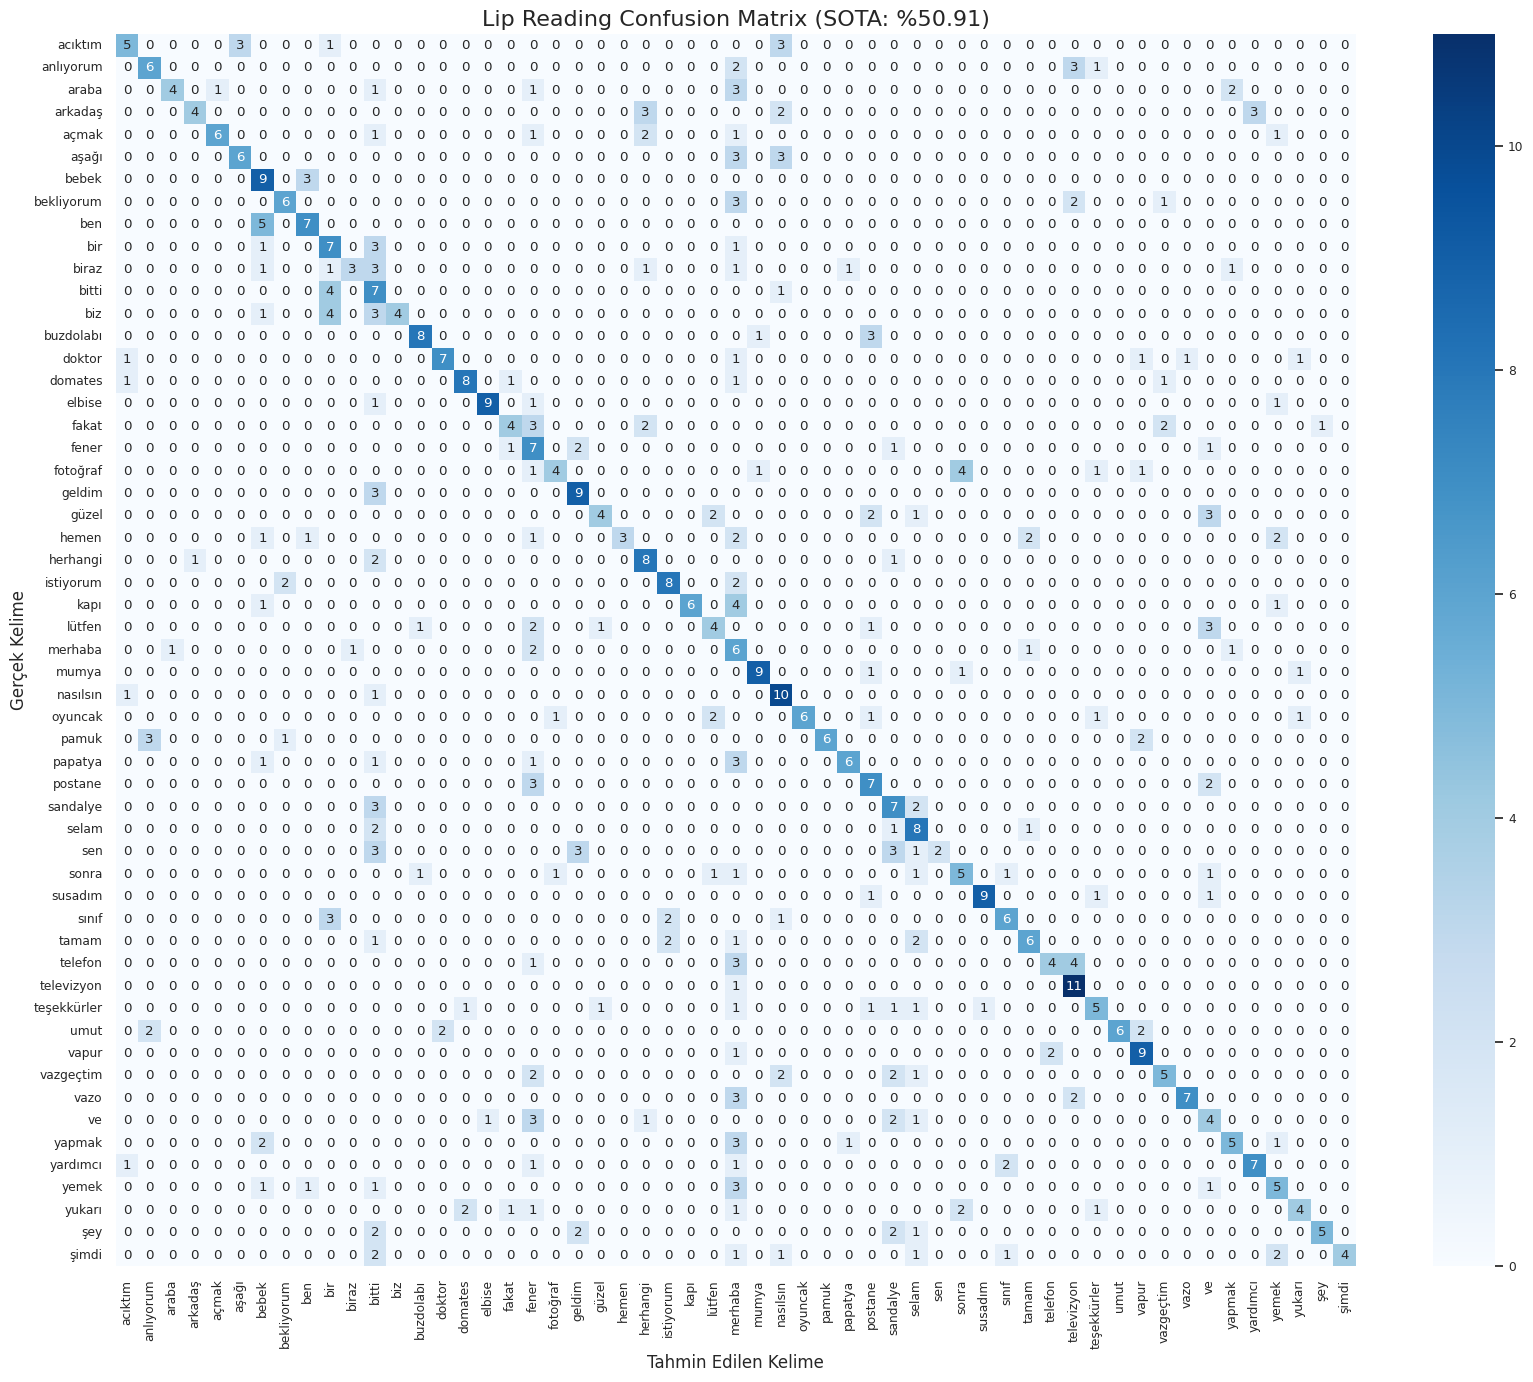


✅ Karmaşıklık matrisi 'confusion_matrix_v3.png' olarak Drive'a kaydedildi.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 55
model = LipReadingModel(num_classes=num_classes).to(device)

def generate_evaluation_metrics(model, loader, class_list, save_path):
    print("🔄 Değerlendirme için en iyi model yükleniyor...")
    checkpoint = torch.load(save_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    all_preds = []
    all_labels = []

    print("🧪 Tahminler toplanıyor (bu işlem bir dakika sürebilir)...")
    with torch.no_grad():
        for video, diff, mask, label in loader:
            video, diff, mask, label = video.to(device), diff.to(device), mask.to(device), label.to(device)

            output = model(video, diff, mask)
            preds = torch.argmax(output, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    print("\n📊 SINIFLANDIRMA RAPORU:")
    print(classification_report(all_labels, all_preds, target_names=class_list))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(20, 16))
    sns.set(font_scale=0.8)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_list, yticklabels=class_list)

    plt.title(f'Lip Reading Confusion Matrix (SOTA: %{checkpoint["best_val_acc"]*100:.2f})', fontsize=16)
    plt.ylabel('Gerçek Kelime', fontsize=12)
    plt.xlabel('Tahmin Edilen Kelime', fontsize=12)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.savefig('/content/drive/MyDrive/confusion_matrix_v3.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("\n✅ Karmaşıklık matrisi 'confusion_matrix_v3.png' olarak Drive'a kaydedildi.")

generate_evaluation_metrics(model, val_loader, class_list, "/content/drive/MyDrive/best_lip_transformer_model_V3.pth")

Test with 2 layer

In [ ]:
import random
import torch

save_path = "/content/drive/MyDrive/best_lip_transformer_model_V3.pth"
checkpoint = torch.load(save_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

n = 15 
indices = random.sample(range(len(val_dataset)), n)

correct_top1 = 0
correct_top3 = 0

print(f"{'='*60}\n🚀 CANLI TEST BAŞLIYOR (SOTA V3: %{checkpoint['best_val_acc']*100:.2f})\n{'='*60}")

with torch.no_grad():
    with torch.amp.autocast('cuda'): 
        for idx in indices:
            video, diff, mask, label_idx = val_dataset[idx]
            gercek = class_list[label_idx]

            video = video.unsqueeze(0).to(device)
            diff  = diff.unsqueeze(0).to(device)
            mask  = mask.unsqueeze(0).to(device)

            output = model(video, diff, mask)
            probs  = torch.softmax(output, dim=1)
            top3   = probs.topk(3)

            tahmin1 = class_list[top3.indices[0][0].item()]
            tahmin3 = [class_list[i.item()] for i in top3.indices[0]]
            prob1   = top3.values[0][0].item() * 100

            t1_ikon = "✅" if tahmin1 == gercek else "❌"
            t3_ikon = "✅" if gercek in tahmin3 else "❌"

            if tahmin1 == gercek: correct_top1 += 1
            if gercek in tahmin3: correct_top3 += 1

            print(f"{t1_ikon} Top1 | {t3_ikon} Top3 | Gerçek: {gercek:12s} | Tahmin: {tahmin1:12s} | Güven: %{prob1:.1f}")

print(f"\n{'='*60}")
print(f"🎯 Toplam {n} test | Top-1: {correct_top1}/{n} (%{correct_top1/n*100:.0f}) | Top-3: {correct_top3}/{n} (%{correct_top3/n*100:.0f})")

🚀 CANLI TEST BAŞLIYOR (SOTA V3: %50.91)
✅ Top1 | ✅ Top3 | Gerçek: sandalye     | Tahmin: sandalye     | Güven: %53.0
❌ Top1 | ❌ Top3 | Gerçek: yardımcı     | Tahmin: acıktım      | Güven: %41.7
✅ Top1 | ✅ Top3 | Gerçek: geldim       | Tahmin: geldim       | Güven: %14.2
❌ Top1 | ❌ Top3 | Gerçek: umut         | Tahmin: anlıyorum    | Güven: %53.2
✅ Top1 | ✅ Top3 | Gerçek: teşekkürler  | Tahmin: teşekkürler  | Güven: %40.6
❌ Top1 | ❌ Top3 | Gerçek: hemen        | Tahmin: ben          | Güven: %67.5
✅ Top1 | ✅ Top3 | Gerçek: bitti        | Tahmin: bitti        | Güven: %68.4
✅ Top1 | ✅ Top3 | Gerçek: şey          | Tahmin: şey          | Güven: %76.9
✅ Top1 | ✅ Top3 | Gerçek: elbise       | Tahmin: elbise       | Güven: %38.8
✅ Top1 | ✅ Top3 | Gerçek: bir          | Tahmin: bir          | Güven: %78.6
✅ Top1 | ✅ Top3 | Gerçek: nasılsın     | Tahmin: nasılsın     | Güven: %63.4
✅ Top1 | ✅ Top3 | Gerçek: kapı         | Tahmin: kapı         | Güven: %39.7
❌ Top1 | ❌ Top3 | Gerçek: yapmak    